# Intra-Subset Analysis 

This notebook loads a benchmark with pre-defined subsets, and measures each subset's [internal consistency reliability](https://www.statisticshowto.com/internal-consistency/), or how well instances in the subset produce similar model rankings.

We'll try three different approaches to measure each subset's internal consistency reliability:

1. Split-halves Kendall's Tau
2. Bootstrapped Kendall's Tau
3. Mini-batch Kendall's W

## Set Up

Import packages.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import kendalltau
from tqdm import tqdm
from src.utils.enums import Dataset
from src.utils.data import (
    get_metadata_mask,
    get_unique_metadata_values,
    load_dataset,
)
from src.utils.metrics import kendallw
from src.utils.model import load_model_scores
from src.utils.path import build_plot_path
from src.utils.plot import plot_histogram

Specify the benchmark to analyze, and load its dataset and model scores.

In [2]:
dataset = Dataset.MMLU
dataset_df = load_dataset(dataset)
model_scores_df = load_model_scores(dataset)
models = model_scores_df.columns.tolist()

print(f"Number of instances: {(num_instances := len(dataset_df))}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {(num_models := len(models))}")
display(model_scores_df.head())

assert len(dataset_df) == len(model_scores_df)

Number of instances: 14042


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of models: 9


,claude-3.5-haiku,gpt-3.5-turbo,gpt-4o-mini-2024-07-18,Llama-3.1-70B-Instruct,Llama-3.1-8B-Instruct,Llama-3.1-Tulu-3-70B,Llama-3.1-Tulu-3-8B,Qwen2.5-72B-Instruct,Qwen2.5-7B-Instruct
0,1,0,1,1,0,1,0,1,0
1,0,0,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,0,1
3,0,0,0,0,0,1,0,1,1
4,1,0,1,1,1,1,0,1,1


View the dataset's subsets.

In [3]:
subset_col = dataset.subset_col
is_ds_1000 = dataset == Dataset.DS_1000

subsets = (
    get_unique_metadata_values(dataset_df, subset_col)
    if is_ds_1000
    else dataset_df[subset_col].unique()
)

plural = "libraries" if is_ds_1000 else f"{subset_col}s"
print(f"{(num_subsets := len(subsets))} {plural}: {subsets}")

57 subjects: <ArrowStringArray>
[                   'abstract_algebra',                             'anatomy',
                           'astronomy',                     'business_ethics',
                  'clinical_knowledge',                     'college_biology',
                   'college_chemistry',            'college_computer_science',
                 'college_mathematics',                    'college_medicine',
                     'college_physics',                   'computer_security',
                  'conceptual_physics',                        'econometrics',
              'electrical_engineering',              'elementary_mathematics',
                        'formal_logic',                        'global_facts',
                 'high_school_biology',               'high_school_chemistry',
        'high_school_computer_science',        'high_school_european_history',
               'high_school_geography', 'high_school_government_and_politics',
          'high_scho

## Analyses

### 1. Split-Halves Kendall's Tau

For each subset, do the following:
1. Randomly split the subset's instances into two mutually exclusive halves
2. Calculate the model rankings on Subset A and Subset B
3. Compute the Kendall's Tau between Subset A and Subset B
4. Repeat steps 1-3 for many iterations and average the Kendall's Taus across all iterations

In [4]:
num_trials = 500

kwargs = {
    "desc": "Computing split-half Kendall's Taus",
    "total": num_subsets,
    "unit": plural,
}

split_half_results = []

for subset in tqdm(subsets, **kwargs):
    mask = (
        get_metadata_mask(dataset_df, subset_col, subset)
        if is_ds_1000
        else dataset_df[subset_col] == subset
    )
    subset_scores = model_scores_df[mask]
    subset_size = len(subset_scores)

    taus = []
    for trial in range(num_trials):
        rng = np.random.default_rng(trial)
        shuffled_indices = rng.permutation(subset_size)
        half = subset_size // 2
        scores_a = subset_scores.iloc[shuffled_indices[:half]].mean()
        scores_b = subset_scores.iloc[shuffled_indices[half:]].mean()
        tau, _ = kendalltau(scores_a, scores_b)
        taus.append(tau)

    split_half_results.append(
        {
            "subset": subset,
            "mean_kendall_tau": np.mean(taus),
            "std_kendall_tau": np.std(taus),
            "num_instances": subset_size,
        }
    )

split_half_df = pd.DataFrame(split_half_results)
split_half_df.head()

Computing split-half Kendall's Taus: 100%|██████████| 57/57 [00:24<00:00,  2.32subjects/s]


,subset,mean_kendall_tau,std_kendall_tau,num_instances
0,abstract_algebra,0.657107,0.096141,100
1,anatomy,0.553136,0.138637,135
2,astronomy,0.714548,0.108016,152
3,business_ethics,0.395741,0.176547,100
4,clinical_knowledge,0.600180,0.132329,265


Plot a histogram showing the distribution of split-half Kendall's Taus across subsets.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\intra_subset_analysis\MMLU\split_halves-kendall_tau-histogram.png


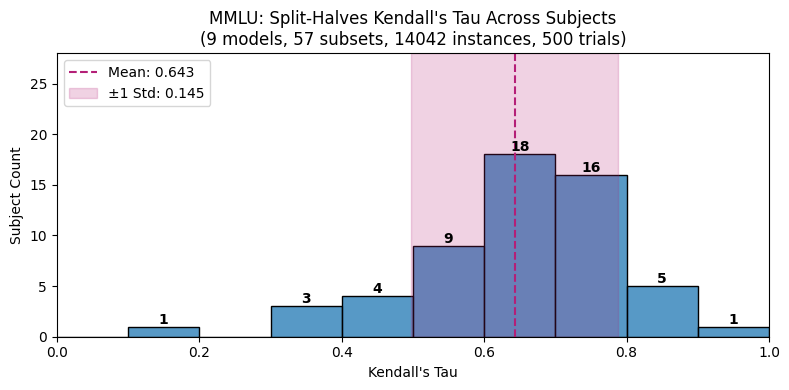

In [ ]:
num_models = len(model_scores_df.columns)
num_instances = len(dataset_df)
colors = sns.color_palette("tab10")

xlim = (-1, 1) if min(split_half_df["mean_kendall_tau"]) < 0 else (0, 1)

ylim = {
    Dataset.DS_1000: (0, num_subsets),
    Dataset.MATH: (0, num_subsets),
    Dataset.MMLU: (0, num_subsets // 2),
}[dataset]

plot_histogram(
    split_half_df["mean_kendall_tau"],
    xlabel="Kendall's Tau",
    ylabel=f"{subset_col.capitalize()} Count",
    title=(
        f"{dataset}: Split-Halves Kendall's Tau Across {plural.capitalize()}"
        f"\n({num_models} models, {num_subsets} subsets, {num_instances} instances)"
    ),
    annotate=True,
    mean=split_half_df["mean_kendall_tau"].mean(),
    std=split_half_df["mean_kendall_tau"].std(),
    xlim=xlim,
    ylim=ylim,
    color=colors[0],
)

analysis = "intra_subset_analysis"
plot_name = f"split-halves_kendall-tau_histogram_num-trials={num_trials}"
file_path = build_plot_path(
    dataset,
    analysis,
    plot_name=plot_name,
)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()

### 2. Bootstrapped Kendall's Tau

For each subset, do the following:
1. Compute the model ranking across all instances. We'll use this as our reference model ranking 
2. Create $B$ bootstrapped samples
3. Compute the Kendall's Tau between each bootstrapped sample's model ranking and the reference model ranking
4. Repeat steps 1-3 for $B$ iterations and average the Kendall's Taus

**NOTE:** Boostrapping *may* produce Kendall's Taus that are biased upward. See [here](https://stats.stackexchange.com/questions/88980/why-on-average-does-each-bootstrap-sample-contain-roughly-two-thirds-of-observat) for an explanation.

In [6]:
num_bootstrap = 500

kwargs = {
    "desc": "Computing bootstrapped Kendall's Taus",
    "total": num_subsets,
    "unit": plural,
}

bootstrap_results = []

for subset in tqdm(subsets, **kwargs):
    mask = (
        get_metadata_mask(dataset_df, subset_col, subset)
        if is_ds_1000
        else dataset_df[subset_col] == subset
    )
    subset_scores = model_scores_df[mask]
    n = len(subset_scores)

    # Reference ranking: model ranking across all instances in the subset
    reference_scores = subset_scores.mean()

    taus = []
    for b in range(num_bootstrap):
        rng = np.random.default_rng(b)
        bootstrap_indices = rng.integers(0, n, size=n)
        bootstrap_scores = subset_scores.iloc[bootstrap_indices].mean()
        tau, _ = kendalltau(reference_scores, bootstrap_scores)
        taus.append(tau)

    bootstrap_results.append(
        {
            "subset": subset,
            "mean_kendall_tau": np.mean(taus),
            "std_kendall_tau": np.std(taus),
            "num_instances": n,
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df.head()

Computing bootstrapped Kendall's Taus: 100%|██████████| 57/57 [00:17<00:00,  3.22subjects/s]


,subset,mean_kendall_tau,std_kendall_tau,num_instances
0,abstract_algebra,0.828856,0.090694,100
1,anatomy,0.768889,0.112580,135
2,astronomy,0.858250,0.084920,152
3,business_ethics,0.735997,0.127724,100
4,clinical_knowledge,0.804789,0.096392,265


Plot a histogram showing the distribution of bootstrapped Kendall's Taus across subsets.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\intra_subset_analysis\MMLU\bootstrap-kendall_tau-histogram.png


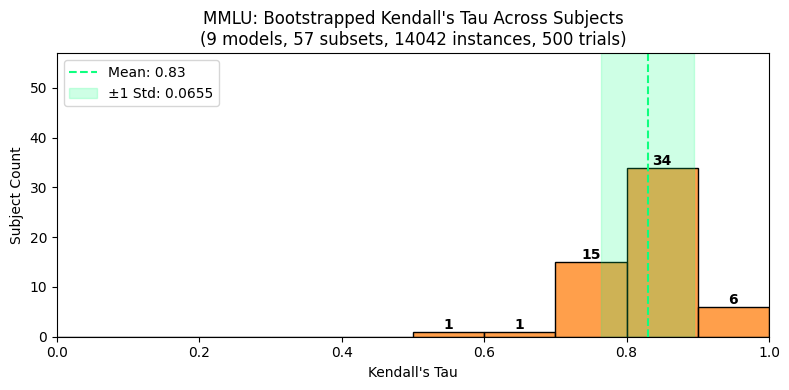

In [ ]:
xlim = (-1, 1) if min(bootstrap_df["mean_kendall_tau"]) < 0 else (0, 1)

ylim = {
    Dataset.DS_1000: (0, num_subsets),
    Dataset.MATH: (0, num_subsets),
    Dataset.MMLU: (0, num_subsets),
}[dataset]

plot_histogram(
    bootstrap_df["mean_kendall_tau"],
    xlabel="Kendall's Tau",
    ylabel=f"{subset_col.capitalize()} Count",
    title=(
        f"{dataset}: Bootstrapped Kendall's Tau Across {plural.capitalize()}"
        f"\n({num_models} models, {num_subsets} subsets, {num_instances} instances, {num_trials} trials)"
    ),
    annotate=True,
    mean=bootstrap_df["mean_kendall_tau"].mean(),
    std=bootstrap_df["mean_kendall_tau"].std(),
    xlim=xlim,
    ylim=ylim,
    color=colors[1],
)

analysis = "intra_subset_analysis"
plot_name = f"bootstrap_kendall-tau_histogram_num-trials={num_trials}"
file_path = build_plot_path(
    dataset,
    analysis,
    plot_name=plot_name,
)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()

### 3. Mini-Batch Kendall's W

For each subset, do the following:
1. Split the subset's instances into $K$ random folds
2. Compute each fold's model rankings 
3. Compute Kendall's $W$ across all $K$ folds
4. Repeat steps 1-3 for many iterations and average the Kendall's $W$ values

In [8]:
num_folds = 5
num_iterations = 500

kwargs = {
    "desc": "Computing mini-batch Kendall's W",
    "total": num_subsets,
    "unit": plural,
}

minibatch_w_results = []

for subset in tqdm(subsets, **kwargs):
    mask = (
        get_metadata_mask(dataset_df, subset_col, subset)
        if is_ds_1000
        else dataset_df[subset_col] == subset
    )
    subset_scores = model_scores_df[mask]
    subset_size = len(subset_scores)

    kendallw_values = []
    for trial in range(num_iterations):
        rng = np.random.default_rng(trial)
        shuffled_indices = rng.permutation(subset_size)
        folds = np.array_split(shuffled_indices, num_folds)

        # Each row is one fold's mean model scores: shape (num_folds, num_models)
        fold_scores = np.array(
            [subset_scores.iloc[fold].mean().values for fold in folds]
        )

        kendallw_values.append(kendallw(fold_scores))

    minibatch_w_results.append(
        {
            "subset": subset,
            "mean_kendallw": np.mean(kendallw_values),
            "std_kendallw": np.std(kendallw_values),
            "num_instances": subset_size,
        }
    )

minibatch_w_df = pd.DataFrame(minibatch_w_results)
minibatch_w_df.head()

Computing mini-batch Kendall's W: 100%|██████████| 57/57 [00:52<00:00,  1.08subjects/s]


,subset,mean_kendallw,std_kendallw,num_instances
0,abstract_algebra,0.778446,0.046074,100
1,anatomy,0.576551,0.072718,135
2,astronomy,0.792418,0.046868,152
3,business_ethics,0.423481,0.073291,100
4,clinical_knowledge,0.648431,0.076045,265


Plot a histogram showing the distribution of mini-batch Kendall's $W$ values across subsets.

Saved plot to C:\Users\Mike\vscode\EvalTree\results\plots\intra_subset_analysis\MMLU\mini-batch-kendall_w-histogram.png


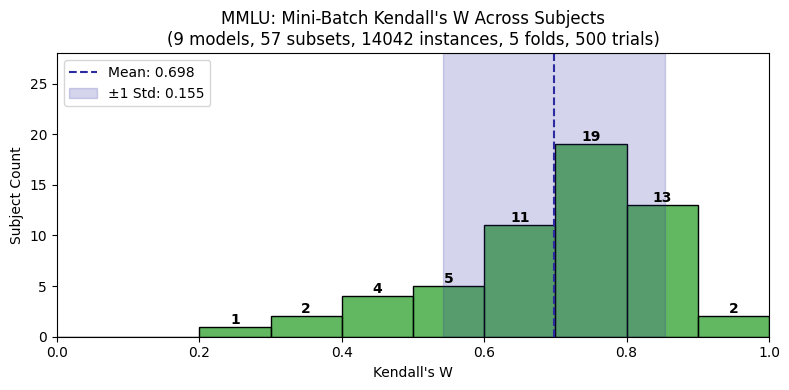

In [ ]:
xlim = (0, 1)

ylim = {
    Dataset.DS_1000: (0, num_subsets),
    Dataset.MATH: (0, num_subsets),
    Dataset.MMLU: (0, num_subsets // 2),
}[dataset]

plot_histogram(
    minibatch_w_df["mean_kendallw"],
    xlabel="Kendall's W",
    ylabel=f"{subset_col.capitalize()} Count",
    title=(
        f"{dataset}: Mini-Batch Kendall's W Across {plural.capitalize()}"
        f"\n({num_models} models, {num_subsets} subsets, {num_instances} instances, {num_folds} folds, {num_trials} trials)"
    ),
    annotate=True,
    mean=minibatch_w_df["mean_kendallw"].mean(),
    std=minibatch_w_df["mean_kendallw"].std(),
    xlim=xlim,
    ylim=ylim,
    color=colors[2],
)

analysis = "intra_subset_analysis"
plot_name = (
    f"mini-batch_kendall-w_histogram_num-folds={num_folds}_num-trials={num_iterations}"
)
file_path = build_plot_path(
    dataset,
    analysis,
    plot_name=plot_name,
)
plt.savefig(file_path)
print(f"Saved plot to {file_path}")
plt.show()